# 4. Valores faltantes

Sección 9.10.4.1.4 del enunciado. Se cuantifican los faltantes de las 154 columnas del archivo
intermedio (las 152 originales más `antig_credito_meses` e `issue_year`), se examina
su patrón (por columnas, por filas y por año de emisión), se evalúa si dependen de la variable
objetivo y se contrasta la hipótesis de faltantes completamente al azar (MCAR) con la prueba de
Little (1988). El capítulo termina con el plan de tratamiento por variable.

In [1]:
import sys
import warnings

sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

import estadistica as est
import utils as u

u.estilo()
pd.set_option("display.max_columns", 30, "display.width", 180, "display.max_rows", 200)
df = u.cargar_prestamos()
df.loc[(df["dti"] < 0) | (df["dti"] > 100), "dti"] = np.nan
print(f"{len(df):,} préstamos x {df.shape[1]} columnas")

1,348,059 préstamos x 154 columnas


## 4.1 Faltantes por columna

In [2]:
falt = pd.DataFrame({"n_faltantes": df.isna().sum(), "%": 100 * df.isna().mean()})
falt["grupo"] = pd.cut(falt["%"], [-0.1, 0, 5, 30, 70, 100],
                       labels=["0 %", "(0, 5] %", "(5, 30] %", "(30, 70] %", "> 70 %"])
print(falt["grupo"].value_counts().sort_index().to_string())
falt[falt["n_faltantes"] > 0].sort_values("%", ascending=False).round(2)

grupo
0 %           40
(0, 5] %      30
(5, 30] %     26
(30, 70] %    16
> 70 %        42


,n_faltantes,%,grupo
member_id,1348059,100.00,> 70 %
next_pymnt_d,1345310,99.80,> 70 %
orig_projected_additional_accrued_interest,1344300,99.72,> 70 %
payment_plan_start_date,1342305,99.57,> 70 %
hardship_length,1342305,99.57,> 70 %
hardship_dpd,1342305,99.57,> 70 %
hardship_loan_status,1342305,99.57,> 70 %
hardship_start_date,1342305,99.57,> 70 %
hardship_payoff_balance_amount,1342305,99.57,> 70 %
hardship_last_payment_amount,1342305,99.57,> 70 %


De las 154 columnas del archivo intermedio (152 más `antig_credito_meses` e `issue_year`), 40 no
tienen faltantes, 56 tienen menos de 30 %, 16 entre 30 % y 70 % y 42 más de 70 %. Las columnas
con más de 70 % son, salvo tres, de tres tipos: variables de coprestatario (`sec_app_*`,
`*_joint`, 98,1-99,5 %), variables de *hardship* y *settlement* (97,5-99,7 %, además posteriores a
la originación) y variables de "meses desde el último evento" (`mths_since_last_record`,
`mths_since_recent_bc_dlq`, `mths_since_last_major_derog`), cuyo faltante significa que el evento
nunca ocurrió. Las otras tres son `member_id` (vacía), `desc` (texto libre, 90,7 %) y
`next_pymnt_d` (99,8 %, posterior a la originación).

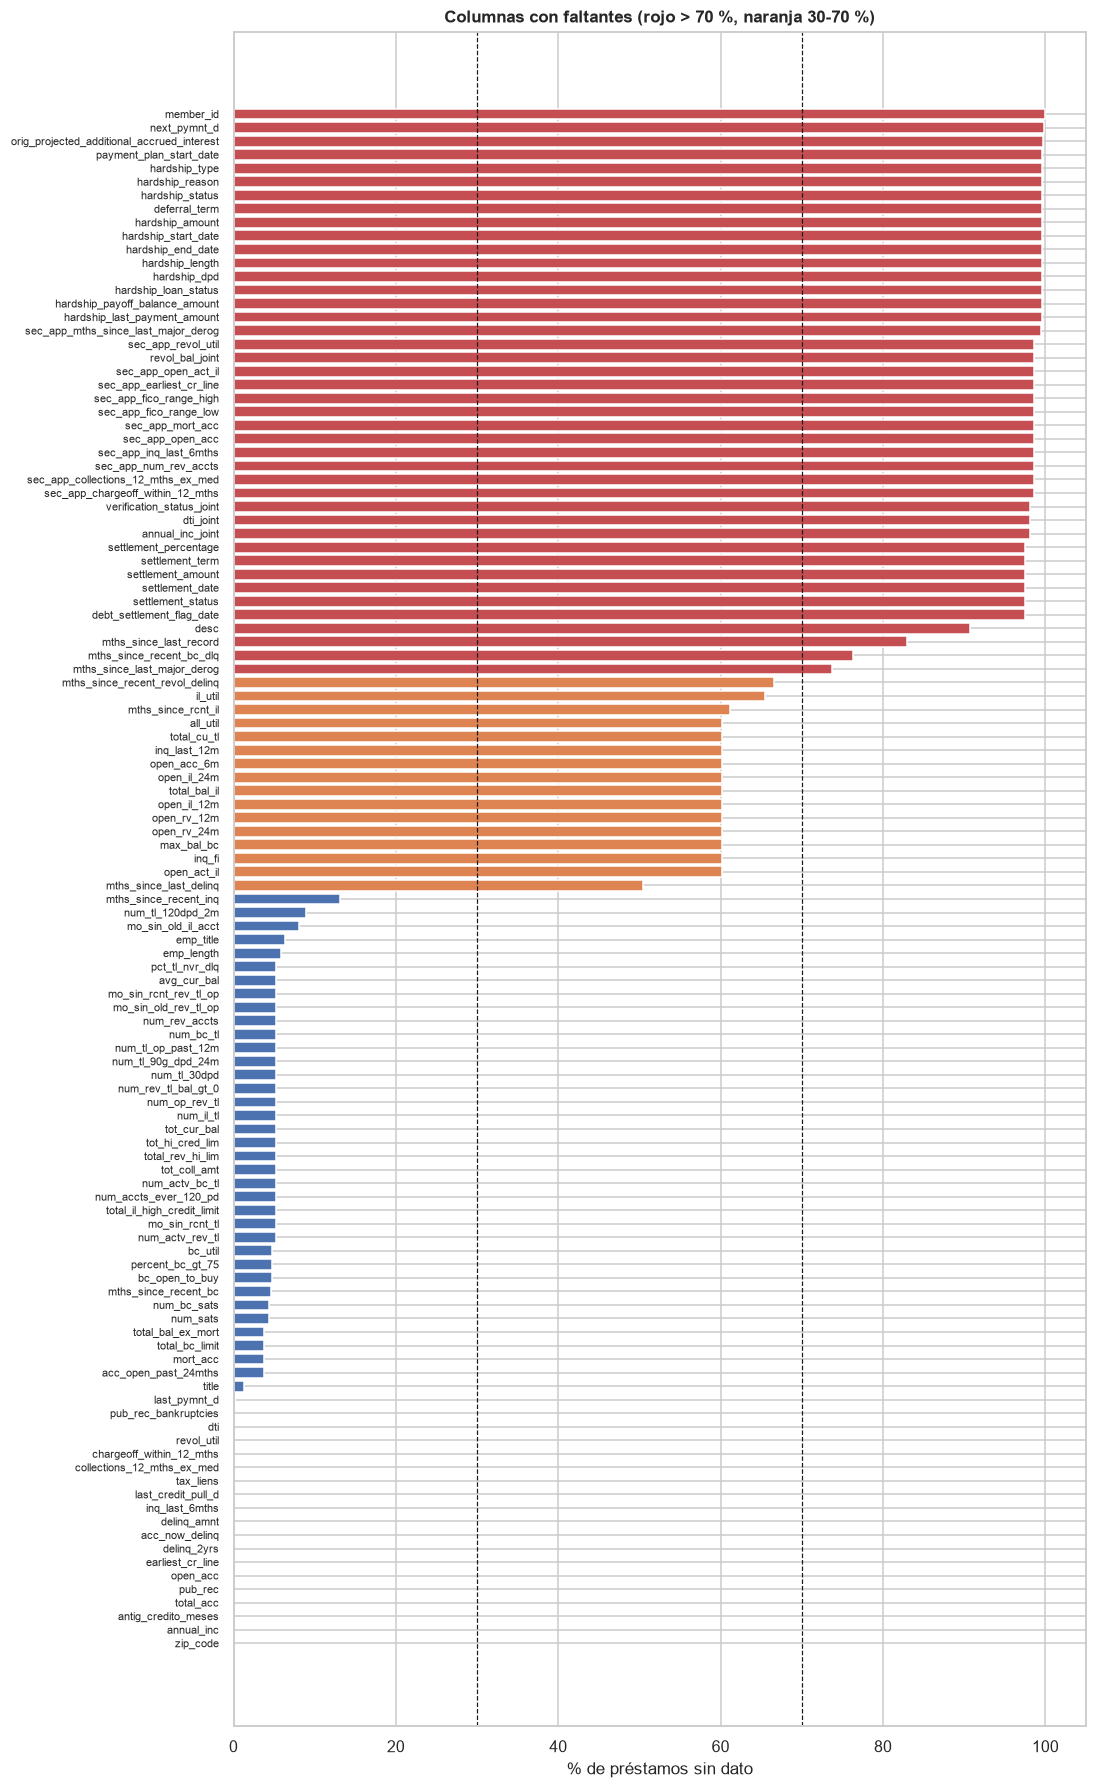

In [3]:
con_falt = falt[falt["%"] > 0].sort_values("%")
fig, ax = plt.subplots(figsize=(10, 20))
colores = np.select([con_falt["%"] > 70, con_falt["%"] > 30], ["#C44E52", "#DD8452"], "#4C72B0")
ax.barh(con_falt.index, con_falt["%"], color=colores)
for x in (30, 70):
    ax.axvline(x, color="k", ls="--", lw=0.8)
ax.set_xlabel("% de préstamos sin dato")
ax.set_title("Columnas con faltantes (rojo > 70 %, naranja 30-70 %)")
ax.tick_params(axis="y", labelsize=7)
u.guardar_fig(fig, "04_faltantes_columnas")
plt.show()

## 4.2 Patrón de los faltantes

### 4.2.1 Matriz de nulidad

La matriz muestra 2.000 préstamos elegidos al azar y **ordenados por fecha de emisión** (de arriba,
2007, a abajo, 2018), para las columnas con faltantes estrictamente entre 0 % y 100 %, sin las de
fuga de información ni las de texto libre. Cada franja blanca es un
dato ausente.

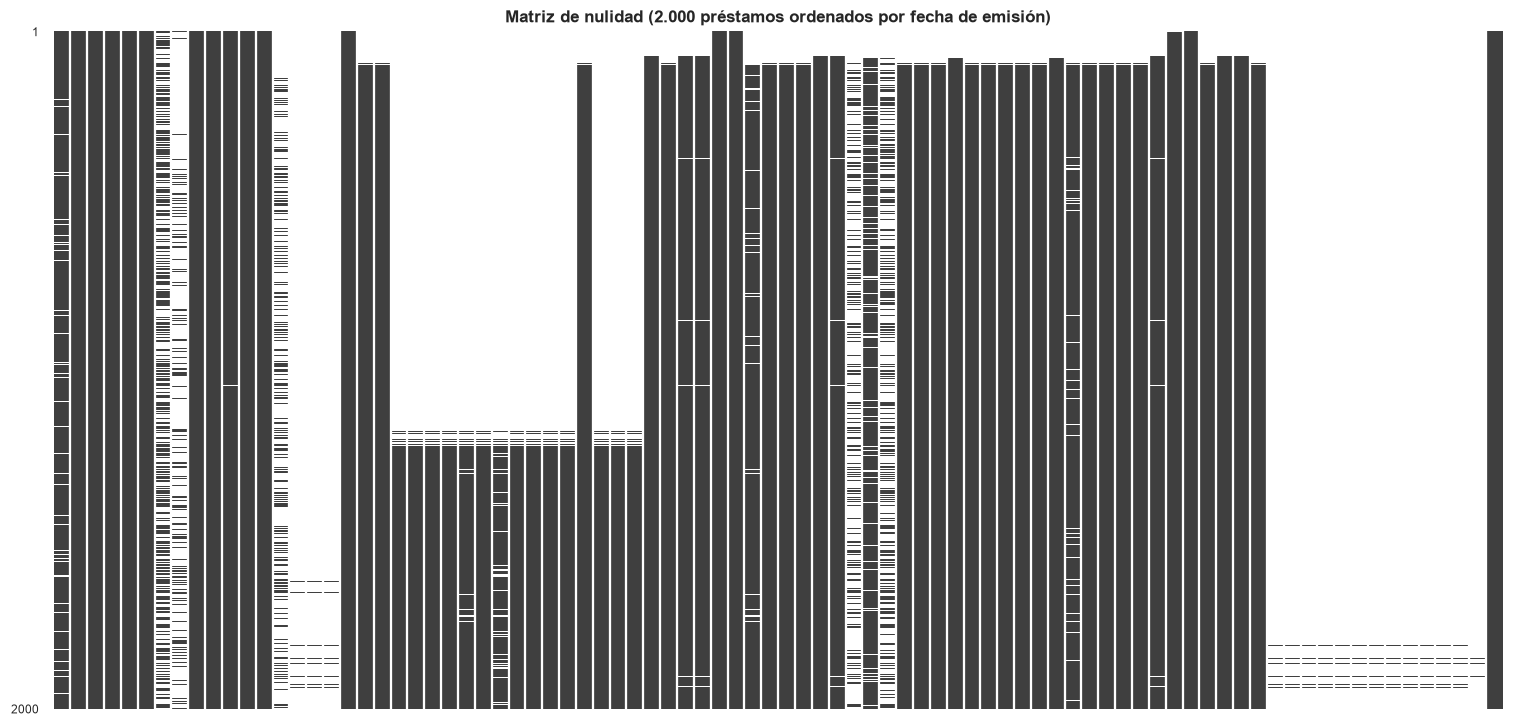

In [4]:
cols_patron = [c for c in falt.index if 0 < falt.loc[c, "%"] < 100 and c not in u.FUGA
               and c not in ("desc", "emp_title", "title", "zip_code")]
orden_fecha = pd.to_datetime(df["issue_d"], format="%b-%Y")
m = df.assign(_f=orden_fecha).sample(2000, random_state=u.SEMILLA).sort_values("_f")
ax = msno.matrix(m[cols_patron], figsize=(17, 8), fontsize=7, sparkline=False)
ax.set_title("Matriz de nulidad (2.000 préstamos ordenados por fecha de emisión)", weight="bold")
plt.savefig(u.FIGURAS / "04_msno_matriz.png")
plt.show()

La matriz muestra que los faltantes **no están dispersos al azar**: forman bloques horizontales.
Los préstamos más antiguos (parte superior) carecen de todo el bloque de variables del buró de
crédito que Lending Club empezó a registrar en 2012, y un segundo bloque (`open_acc_6m`,
`il_util`, `all_util`...) solo aparece en los préstamos recientes (parte inferior).

### 4.2.2 Faltantes por año de emisión

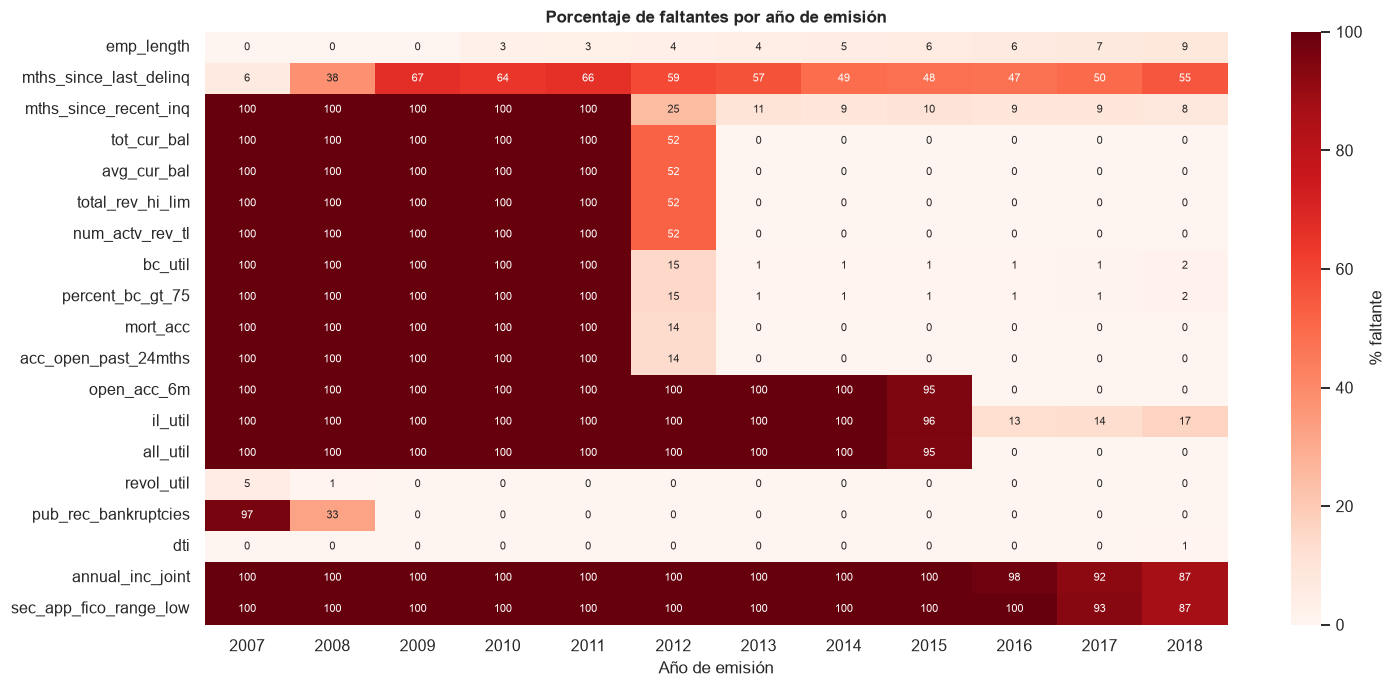

In [5]:
seleccion = ["emp_length", "mths_since_last_delinq", "mths_since_recent_inq", "tot_cur_bal",
             "avg_cur_bal", "total_rev_hi_lim", "num_actv_rev_tl", "bc_util", "percent_bc_gt_75",
             "mort_acc", "acc_open_past_24mths", "open_acc_6m", "il_util", "all_util", "revol_util",
             "pub_rec_bankruptcies", "dti", "annual_inc_joint", "sec_app_fico_range_low"]
por_anio = 100 * df[seleccion].isna().groupby(df["issue_year"]).mean()
fig, ax = plt.subplots(figsize=(15, 7))
sns.heatmap(por_anio.T, cmap="Reds", annot=True, fmt=".0f", annot_kws={"size": 7},
            cbar_kws={"label": "% faltante"}, ax=ax)
ax.set_title("Porcentaje de faltantes por año de emisión")
ax.set_xlabel("Año de emisión")
u.guardar_fig(fig, "04_faltantes_anio")
plt.show()

El mapa por año confirma la causa: los faltantes de `avg_cur_bal`, `total_rev_hi_lim` y demás
variables del buró son 100 % hasta 2011, 52 % en 2012 y cero desde 2013; los de
`acc_open_past_24mths` y `mort_acc` también son 100 % hasta 2011, pero solo 14 % en 2012.
`open_acc_6m`, `il_util` y `all_util` faltan casi por completo hasta 2015 (95 % ese año) y existen
desde 2016. Son faltantes **estructurales**, determinados por la fecha de emisión y no por el
prestatario. `emp_length` es distinto: su faltante crece de 0 % en 2007-2009 a cerca de 9 % en
2018 y depende del solicitante.

### 4.2.3 Correlación de nulidad entre las variables candidatas

El mapa de `missingno` muestra la correlación entre los indicadores de faltante: 1 significa que
dos variables siempre faltan juntas.

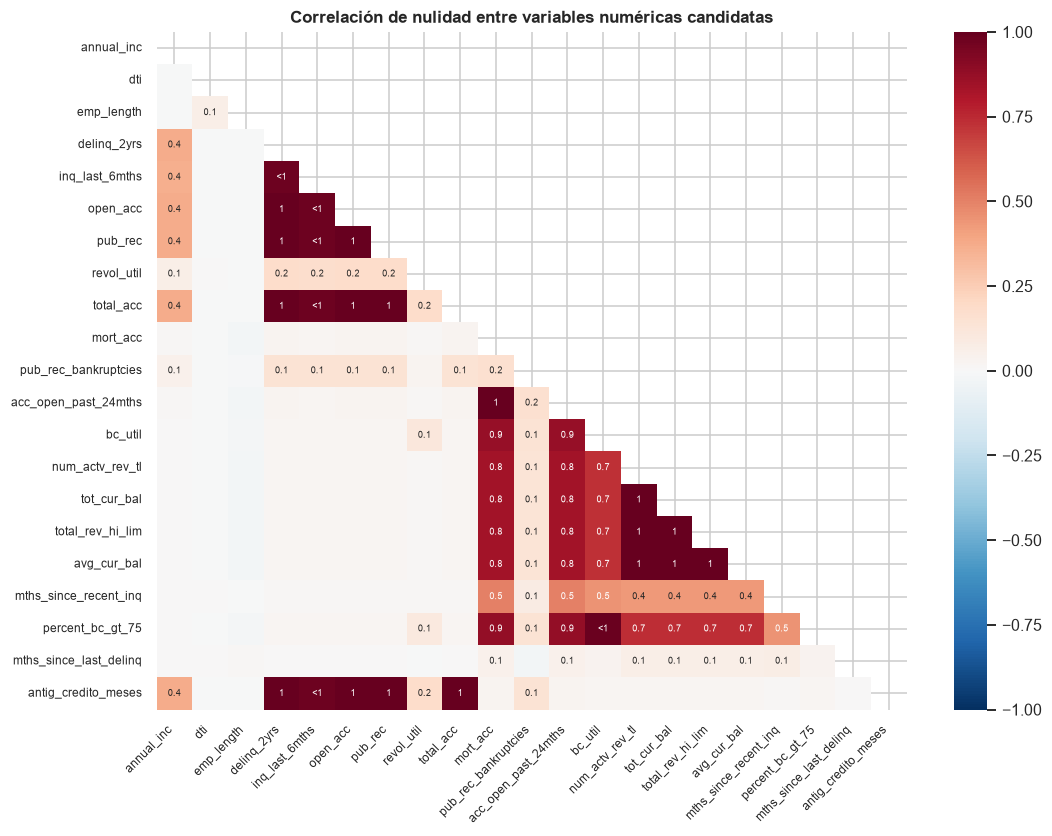

In [6]:
cand = [c for c in u.NUM_EDA if df[c].isna().any()]
ax = msno.heatmap(df[cand], figsize=(11, 8), fontsize=8, cmap="RdBu_r")
ax.set_title("Correlación de nulidad entre variables numéricas candidatas", weight="bold")
plt.savefig(u.FIGURAS / "04_msno_heatmap.png")
plt.show()

Las variables del buró tienen correlaciones de nulidad cercanas a 1 entre sí: faltan juntas,
porque todas provienen del mismo reporte. `emp_length`, `dti` y `mths_since_last_delinq` tienen
correlaciones de nulidad casi nulas con el resto: sus faltantes tienen otros mecanismos.

### 4.2.4 Concentración de faltantes por fila

In [7]:
cand_modelo = [c for c in u.NUM_EDA if c != "mths_since_last_delinq"]
n_falt_fila = df[cand_modelo].isna().sum(axis=1)
dist_filas = n_falt_fila.value_counts().sort_index().rename("préstamos").to_frame()
dist_filas["%"] = (100 * dist_filas["préstamos"] / len(df)).round(3)
dist_filas["tasa_default_%"] = (100 * df.groupby(n_falt_fila)["default"].mean()).round(2)
dist_filas

,préstamos,%,tasa_default_%
0,1073945,79.666,20.34
1,180855,13.416,19.19
2,19527,1.449,22.45
3,3089,0.229,20.72
4,17120,1.270,17.60
5,3118,0.231,13.73
6,301,0.022,21.26
7,67,0.005,26.87
8,7,0.001,14.29
9,47226,3.503,14.82


El 79,7 % de los préstamos no tiene ningún faltante en las variables candidatas y el 13,4 % tiene
uno solo (casi siempre `mths_since_recent_inq` o `emp_length`). Los 47.226 préstamos con nueve
faltantes (3,5 %) son el núcleo de los préstamos antiguos sin bloque de buró; junto con los de
diez o más suman 50.030, los mismos que carecen de `acc_open_past_24mths` y `mort_acc`. Su tasa de
default (14,8 %) es menor que la global, como corresponde a las cohortes antiguas (capítulo 1).
Otros 20.000 préstamos, en las filas de 4 y 5 faltantes, carecen solo de `avg_cur_bal`,
`total_rev_hi_lim`, `tot_cur_bal` y `num_actv_rev_tl` (la parte de 2012 sin ese bloque).

## 4.3 ¿Dependen los faltantes de la variable objetivo?

Para cada variable candidata con faltantes se compara la tasa de default entre los préstamos con
y sin dato, con una prueba chi-cuadrado de independencia entre el indicador de faltante y
`default`. Si los faltantes fueran MCAR, la tasa sería la misma en ambos grupos.

In [8]:
filas = []
for c in cand + ["emp_title"]:
    ind = df[c].isna()
    tabla = pd.crosstab(ind, df["default"])
    chi2, p, _, _ = stats.chi2_contingency(tabla)
    filas.append({"variable": c, "%_faltante": 100 * ind.mean(),
                  "default_con_dato_%": 100 * df.loc[~ind, "default"].mean(),
                  "default_sin_dato_%": 100 * df.loc[ind, "default"].mean(), "chi2": chi2, "p": p})
dep = pd.DataFrame(filas).set_index("variable")
dep["diferencia_pp"] = dep["default_sin_dato_%"] - dep["default_con_dato_%"]
dep.sort_values("diferencia_pp").round(3)

,%_faltante,default_con_dato_%,default_sin_dato_%,chi2,p,diferencia_pp
variable,,,,,,
annual_inc,0.000,19.978,0.000,0.140,0.708,-19.978
inq_last_6mths,0.002,19.979,10.000,1.296,0.255,-9.979
antig_credito_meses,0.002,19.979,10.345,1.135,0.287,-9.634
delinq_2yrs,0.002,19.979,10.345,1.135,0.287,-9.634
open_acc,0.002,19.979,10.345,1.135,0.287,-9.634
pub_rec,0.002,19.979,10.345,1.135,0.287,-9.634
total_acc,0.002,19.979,10.345,1.135,0.287,-9.634
mths_since_recent_inq,13.117,20.718,15.078,3056.499,0.000,-5.640
acc_open_past_24mths,3.711,20.159,15.285,715.651,0.000,-4.874


En cinco grupos de variables la tasa de default difiere entre préstamos con y sin dato, con
p < 0,01:

* **`emp_length`**: sin antigüedad laboral declarada, el default sube de 19,5 % a 26,9 %
  (+7,4 puntos). El faltante es informativo, probablemente porque incluye a solicitantes sin
  empleo formal. Se imputa la mediana y se añade el indicador `emp_length_faltante`.
* **`mths_since_recent_inq`**: sin consultas recientes registradas, el default baja de 20,7 % a
  15,1 %. Se imputa y se añade `consulta_faltante`.
* **Bloque del buró** (`avg_cur_bal`, `total_rev_hi_lim`, `num_actv_rev_tl`, `mort_acc`,
  `acc_open_past_24mths`): sin dato, el default es 4,4 a 4,9 puntos menor, porque el faltante
  identifica a las cohortes de 2007-2012. Se imputa y se añade un único indicador `buro_faltante`.
* **`mths_since_last_delinq`**: diferencia de −1,4 puntos; se sustituye por `hist_morosidad`.
* `dti` (p = 0,008) y `pub_rec_bankruptcies` (p < 0,001) difieren en 3,6 y 4,5 puntos, pero
  afectan a menos de 0,11 % de los préstamos; basta con la mediana.

En las variables con 29 faltantes (préstamos sin historial en el buró) la diferencia no es
significativa (p > 0,25).

## 4.4 Prueba MCAR de Little

La prueba de Little contrasta $H_0$: los datos son MCAR. Compara la media observada de cada
patrón de faltantes con la media global estimada por máxima verosimilitud (algoritmo EM) y
suma las discrepancias ponderadas, que bajo $H_0$ siguen una $\chi^2$. Se aplica a todas las
variables numéricas candidatas con faltantes (excepto `mths_since_last_delinq`, cuyo faltante
tiene un significado conocido) y a `default`, con los 1.348.059 préstamos. Como verificación de
sensibilidad se repite sobre una muestra de 5.000 préstamos: con un millón de observaciones la
prueba detecta desviaciones mínimas.

In [9]:
vars_little = [c for c in cand if c != "mths_since_last_delinq"] + ["default"]
res_total = est.little_mcar(df[vars_little])
res_muestra = est.little_mcar(df[vars_little].sample(5000, random_state=u.SEMILLA))
pd.DataFrame({"completo (n = 1.348.059)": res_total, "muestra (n = 5.000)": res_muestra}).T

,d2,gl,p_valor,patrones
completo (n = 1.348.059),316617.791665,881.0,0.000000e+00,56.0
muestra (n = 5.000),1648.388747,325.0,1.275182e-175,20.0


La prueba de Little rechaza MCAR con los datos completos ($d^2$ = 316.618 con 881 grados de
libertad, 56 patrones de faltantes) y también en la muestra de 5.000 préstamos (p ≈ 10⁻¹⁷⁵), así
que el rechazo no se debe solo al tamaño de muestra. Los faltantes son, como mínimo, MAR: dependen
de variables observadas (el año de emisión) y, en el caso de `emp_length`, se asocian con el
desenlace. Dos consecuencias para el preprocesamiento:

1. Eliminar las filas con faltantes (análisis de casos completos) no es válido: sesgaría la
   muestra hacia los préstamos posteriores a 2012 y descartaría 20 % de los datos, en contra de
   la condición de usar el conjunto completo.
2. Los indicadores de faltante conservan la información que la imputación por mediana borraría.
   La mediana se calcula solo con el conjunto de entrenamiento.

## 4.5 Plan de tratamiento por variable

La tabla asigna a cada una de las 154 columnas una decisión según estos criterios, en este orden:
(1) decisiones explícitas (identificadores, texto libre, constantes y redundancias de los
capítulos 2 y 3); (2) información posterior a la originación → eliminar por fuga; (3) más de 70 %
de faltantes → eliminar; (4) variables elegidas para el modelo, tratadas según su tipo; (5) entre
30 % y 70 % de faltantes por estar disponibles solo desde 2015-2016 → eliminar; (6) el resto no se
selecciona por redundante o poco informativo.

In [10]:
plan_manual = {
    "id": "identificador: se conserva solo para la partición común",
    "default": "variable objetivo",
    "loan_status": "origen de la variable objetivo: eliminar",
    "member_id": "vacía: eliminar", "url": "identificador: eliminar", "desc": "texto libre: eliminar",
    "title": "texto libre (duplica purpose): eliminar", "emp_title": "texto libre, 380 mil valores: eliminar",
    "zip_code": "3 dígitos, redundante con addr_state: eliminar",
    "policy_code": "constante: eliminar", "issue_d": "fecha de emisión: solo descriptiva",
    "issue_year": "solo descriptiva", "earliest_cr_line": "reemplazada por antig_credito_meses",
    "mths_since_last_delinq": "50 % faltante informativo: indicador hist_morosidad",
    "emp_length": "imputar mediana de entrenamiento + indicador emp_length_faltante",
    "mths_since_recent_inq": "imputar mediana de entrenamiento + indicador consulta_faltante",
    "avg_cur_bal": "imputar mediana + log1p; indicador buro_faltante (bloque de buró anterior a 2012)",
    "dti": "fuera de [0, 100] a faltante; imputar mediana",
    "installment": "redundante con loan_amnt, int_rate y term: eliminar",
    "fico_range_low": "redundante con fico_range_high (r = 1): eliminar",
    "grade": "redundante con int_rate: eliminar", "sub_grade": "redundante con int_rate: eliminar",
    "funded_amnt": "casi idéntica a loan_amnt y posterior a la solicitud: eliminar",
    "bc_util": "redundante con revol_util (r = 0,86): eliminar",
    "percent_bc_gt_75": "redundante con revol_util y bc_util (r > 0,72): eliminar",
    "tot_cur_bal": "redundante con avg_cur_bal (r = 0,84): eliminar",
    "revol_bal": "redundante con total_rev_hi_lim (r = 0,81): eliminar",
    "total_acc": "redundante con open_acc (r = 0,70): eliminar",
}
modelo_num = ["loan_amnt", "term", "int_rate", "emp_length", "annual_inc", "dti", "fico_range_high",
              "delinq_2yrs", "inq_last_6mths", "open_acc", "pub_rec", "revol_util", "mort_acc",
              "pub_rec_bankruptcies", "acc_open_past_24mths", "num_actv_rev_tl", "total_rev_hi_lim",
              "avg_cur_bal", "mths_since_recent_inq", "antig_credito_meses"]
modelo_cat = ["purpose", "home_ownership", "addr_state", "verification_status", "application_type",
              "initial_list_status"]


def decision(c):
    if c in plan_manual:
        return plan_manual[c]
    if c in u.FUGA:
        return "posterior a la originación (fuga): eliminar"
    if falt.loc[c, "%"] > 70:
        return "> 70 % faltante: eliminar"
    if c in modelo_cat:
        return "categórica: agrupar < 1 % y codificar one-hot"
    if c in modelo_num:
        log = " + log1p" if c in ["annual_inc", "total_rev_hi_lim", "avg_cur_bal"] else ""
        return ("imputar mediana de entrenamiento" if falt.loc[c, "%"] > 0 else "sin faltantes") + log
    if falt.loc[c, "%"] > 30:
        return "30-70 % faltante, disponible solo desde 2015-2016: eliminar"
    return "no seleccionada (redundante o poco informativa según el EDA)"


plan = falt[["%"]].round(2).assign(decision=[decision(c) for c in falt.index])
print(plan["decision"].str.split(":").str[-1].str.strip().value_counts().to_string())
plan

decision
eliminar                                                                             91
no seleccionada (redundante o poco informativa según el EDA)                         31
imputar mediana de entrenamiento                                                     10
agrupar < 1 % y codificar one-hot                                                     6
sin faltantes                                                                         4
imputar mediana de entrenamiento + log1p                                              2
solo descriptiva                                                                      2
se conserva solo para la partición común                                              1
imputar mediana de entrenamiento + indicador emp_length_faltante                      1
fuera de [0, 100] a faltante; imputar mediana                                         1
reemplazada por antig_credito_meses                                                   1
indicador hist_morosida

,%,decision
id,0.00,identificador: se conserva solo para la partic...
member_id,100.00,vacía: eliminar
loan_amnt,0.00,sin faltantes
funded_amnt,0.00,casi idéntica a loan_amnt y posterior a la sol...
funded_amnt_inv,0.00,posterior a la originación (fuga): eliminar
term,0.00,sin faltantes
int_rate,0.00,sin faltantes
installment,0.00,"redundante con loan_amnt, int_rate y term: eli..."
grade,0.00,redundante con int_rate: eliminar
sub_grade,0.00,redundante con int_rate: eliminar


De las 154 columnas se eliminan 91 (fuga de información, identificadores, texto libre, variables
constantes, redundantes, con más de 70 % de faltantes o con 30-70 % de faltantes por estar
disponibles solo desde 2015-2016) y otras 31 no se seleccionan por ser redundantes o poco
informativas según el EDA. El modelo usa 20 variables
numéricas originales, 4 indicadores binarios y 6 categóricas.

In [11]:
u.guardar_json({"numericas": modelo_num, "categoricas": modelo_cat,
                "log1p": ["annual_inc", "total_rev_hi_lim", "avg_cur_bal"],
                "indicadores": ["hist_morosidad", "emp_length_faltante", "consulta_faltante",
                                "buro_faltante"]}, u.PROCESSED / "variables_modelo.json")